# **Exploratory Data Analysis**
**Project**: *Retail Revenue Forecasting — Olist Brazil E-commerce*

## 0. Import packages

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data_loader import load_raw_tables, build_master_df, build_daily_series

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

DATA_DIR = "../data/"

In [2]:
tables = load_raw_tables(DATA_DIR)
df     = build_master_df(tables)
daily  = build_daily_series(df)

## 1. Overview dataset

In [3]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,price,...,payment_value,customer_state,customer_city,date,year,month,quarter,hour,dayofweek,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,87285b34884572647811a353c7ac498a,29.99,...,38.71,SP,sao paulo,2017-10-02,2017,10,4,10,0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,595fac2a385ac33a80bd5114aec74eb8,118.70,...,141.46,BA,barreiras,2018-07-24,2018,7,3,20,1,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,aa4383b373c6aca5d8797843e5594415,159.90,...,179.12,GO,vianopolis,2018-08-08,2018,8,3,8,2,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,...,72.20,RN,sao goncalo do amarante,2017-11-18,2017,11,4,19,5,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,65266b2da20d04dbe00c5c2d3bb7859e,19.90,...,28.62,SP,santo andre,2018-02-13,2018,2,1,21,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112642,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,f1d4ce8c6dd66c47bbaa8c6781c2a923,174.90,...,195.00,SP,praia grande,2018-02-06,2018,2,1,12,1,22.0
112643,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,b80910977a37536adeddd63663f916ad,205.99,...,271.01,BA,nova vicosa,2017-08-27,2017,8,3,14,6,24.0
112644,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,...,441.16,RJ,japuiba,2018-01-08,2018,1,1,21,0,17.0
112645,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,...,441.16,RJ,japuiba,2018-01-08,2018,1,1,21,0,17.0


In [4]:
print(f"Total number of transactions : {len(df):,}")
print(f"Unique orders     : {df['order_id'].nunique():,}")
print(f"Unique customers  : {df['customer_id'].nunique():,}")
print(f"Unique categories : {df['category_en'].nunique()}")
print(f"Date range        : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nRevenue statistics:")
print(df["payment_value"].describe().apply(lambda x: f"{x:,.2f}"))

Total number of transactions : 110,194
Unique orders     : 96,477
Unique customers  : 96,477
Unique categories : 73
Date range        : 2016-10-03 → 2018-08-29

Revenue statistics:
count    110,194.00
mean         179.47
std          271.34
min            9.59
25%           65.60
50%          114.34
75%          194.96
max       13,664.08
Name: payment_value, dtype: str


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
product_category_name            1537
category_en                      1537
delivery_days                       8
dtype: int64


## 2. Revenue over time

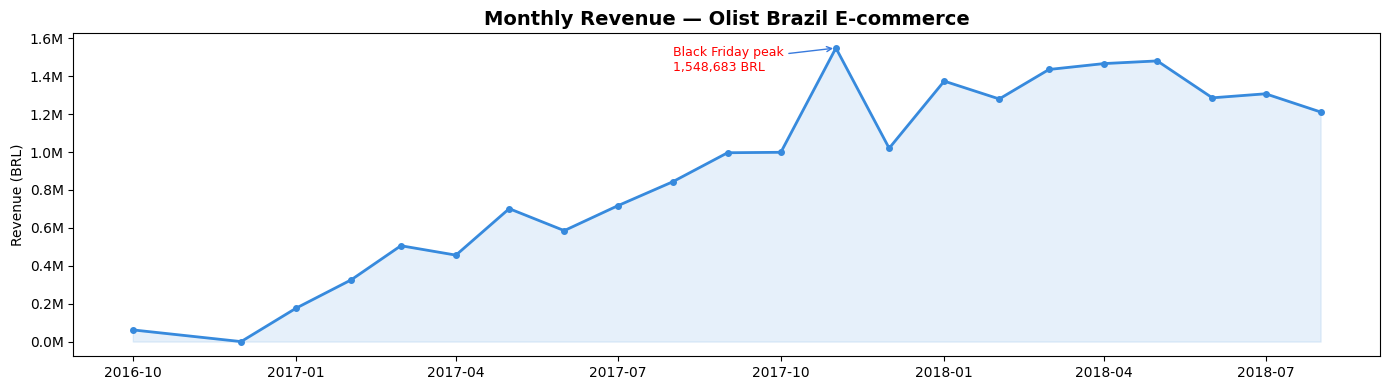

In [6]:
monthly = df.groupby(df["date"].dt.to_period("M"))["payment_value"].sum()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2,
        color="#378ADD", markersize=4)
ax.fill_between(monthly.index, monthly.values, alpha=0.12, color="#378ADD")

# Marking the highest revenue
peak_idx = monthly.values.argmax()
ax.annotate(
    f"Black Friday peak\n{monthly.iloc[peak_idx]:,.0f} BRL",
    xy=(monthly.index[peak_idx], monthly.iloc[peak_idx]),
    xytext=(monthly.index[peak_idx] - pd.DateOffset(months=3),
            monthly.iloc[peak_idx] * 0.92),
    arrowprops=dict(arrowstyle="->", color="#387ADD"),
    fontsize=9, color="red",
)

ax.set_title("Monthly Revenue — Olist Brazil E-commerce", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (BRL)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()
# plt.savefig(IMAGES_DIR / "monthly_revenue.png", dpi=150, bbox_inches="tight")

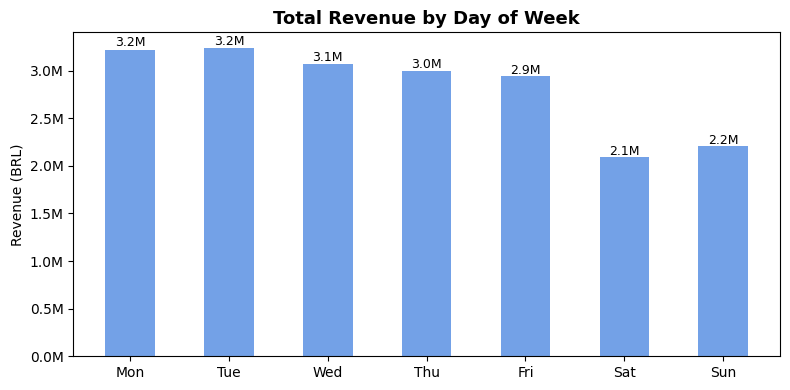

In [7]:
from matplotlib.pyplot import axes

dow_rev = df.groupby("dayofweek")["payment_value"].sum()
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dow_names, dow_rev.values, color="#387ADD", width=0.5, alpha=0.7)
ax.set_title("Total Revenue by Day of Week", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (BRL)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f"{bar.get_height()/1e6:.1f}M", ha="center", fontsize=9)
plt.tight_layout()
plt.show()
# plt.savefig(IMAGES_DIR / "revenue_by_dow.png", dpi=150, bbox_inches="tight")


## 3. Heatmap - revenue over hours&days / week

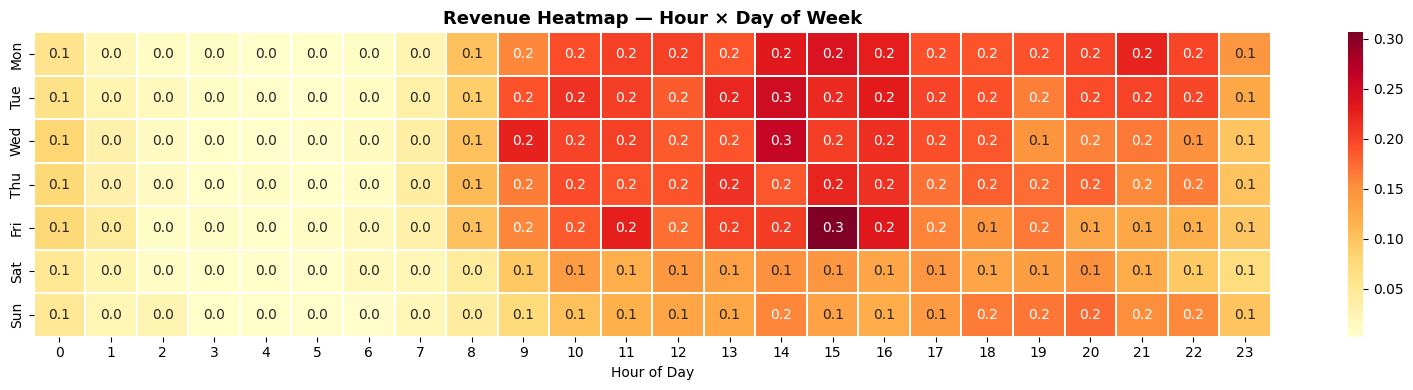

In [8]:
pivot = df.pivot_table(
    values="payment_value",
    index="dayofweek",
    columns="hour",
    aggfunc="sum",
)
pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    pivot / 1e6,
    cmap="YlOrRd",
    ax=ax,
    fmt=".1f",
    annot=True,
    linewidths=0.1
)
ax.set_title("Revenue Heatmap — Hour × Day of Week", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("")
plt.tight_layout()
# plt.savefig(IMAGES_DIR / "heatmap_hour_dow.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Top categories

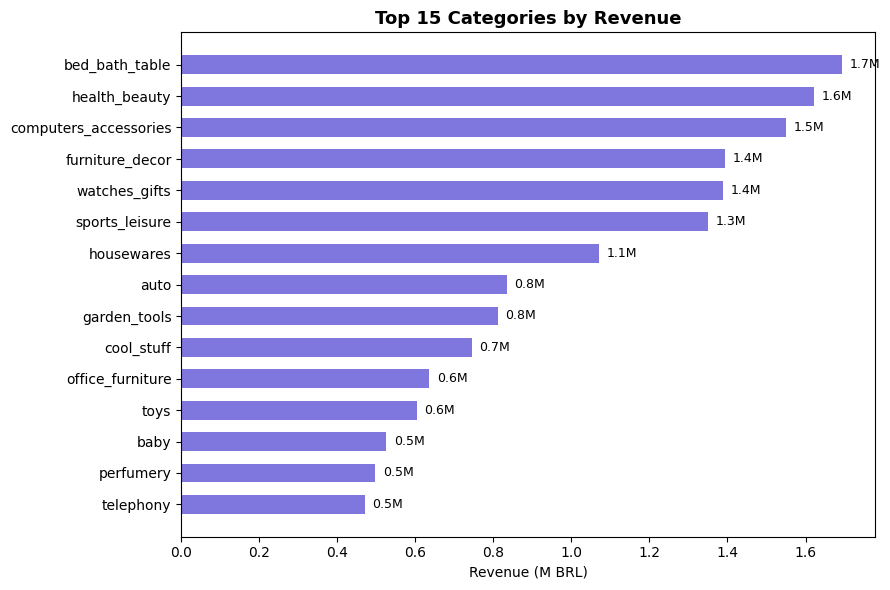

In [9]:
top_cat = (
    df.groupby("category_en")["payment_value"]
    .sum()
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_cat.index, top_cat.values / 1e6, color="#7F77DD", height=0.6)
ax.set_title("Top 15 Categories by Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (M BRL)")
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}M", va="center", fontsize=9)
plt.tight_layout()
# plt.savefig(IMAGES_DIR / "top_categories.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Order Value Distribution

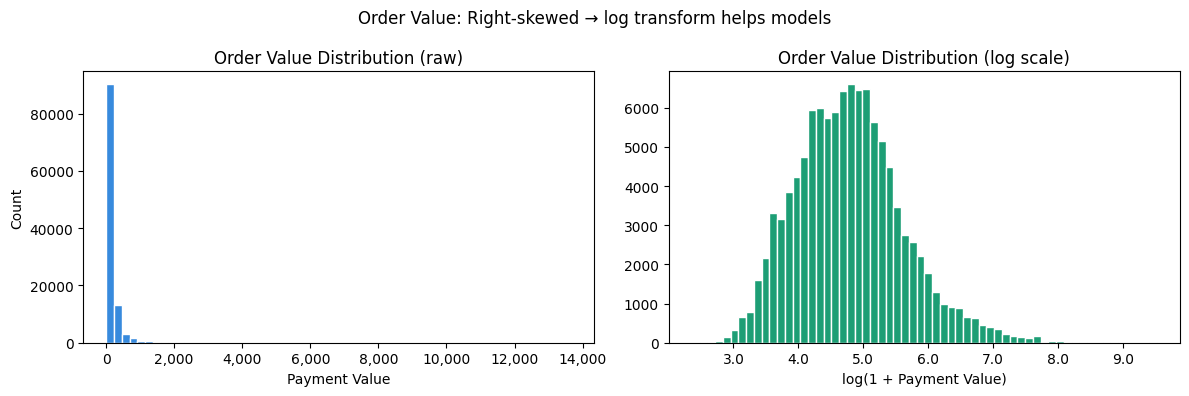

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["payment_value"], bins=60, color="#378ADD", edgecolor="white")
axes[0].set_title("Order Value Distribution (raw)")
axes[0].set_xlabel("Payment Value")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].hist(np.log1p(df["payment_value"]), bins=60, color="#1D9E75", edgecolor="white")
axes[1].set_title("Order Value Distribution (log scale)")
axes[1].set_xlabel("log(1 + Payment Value)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))

plt.suptitle("Order Value: Right-skewed → log transform helps models", fontsize=12)
plt.tight_layout()
# plt.savefig(IMAGES_DIR / "order_value_dist.png", dpi=150, bbox_inches="tight")
plt.show()